<a href="https://colab.research.google.com/github/Chompybits/Homework-Python-block-2/blob/main/homework_VT_vulner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Debug: VT_API_KEY = [KEY_SET]
Debug: VULNERS_API_KEY = [KEY_SET]
>>> ЗАПУСК МОНИТОРИНГА УГРОЗ
[OK] VirusTotal: Данные для 1.1.1.1 получены (Вредоносность: 0).
[!] Vulners API ошибка 403. Использую демо-данные.
[РЕАКЦИЯ] Найдена критическая уязвимость: CVE-FALLBACK (CVSS: 8.5)


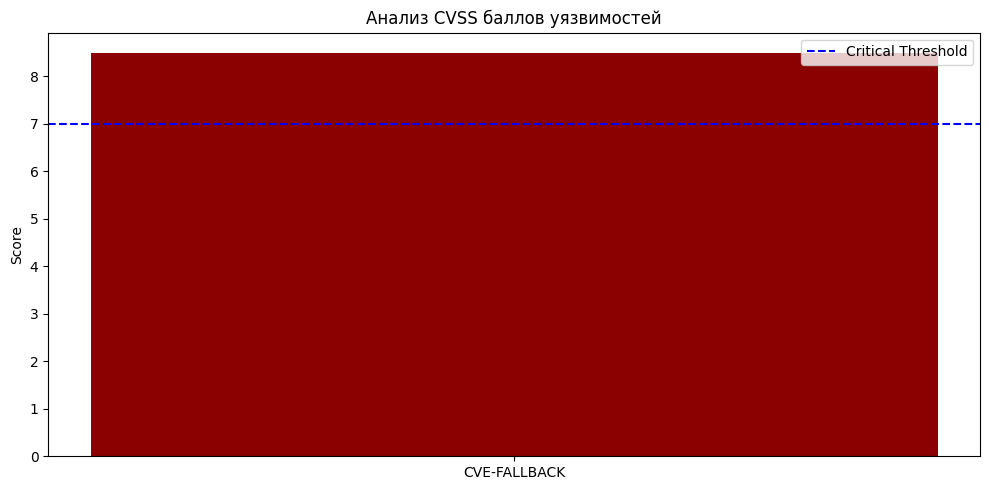

[УСПЕХ] Файлы 'security_report.json' и 'vulnerability_graph.png' созданы.


In [8]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
from google.colab import userdata

# КОНФИГУРАЦИЯ
# Если ключи недоступны то будут использованы демо данные.
# Извлечение API ключей из переменных окружения (например, через Colab Secrets)
VT_API_KEY = userdata.get('VT_API_KEY')
VULNERS_API_KEY = userdata.get('VULNERS_API_KEY')

# Отладочный вывод для проверки ключей
print(f"Debug: VT_API_KEY = {'[KEY_SET]' if VT_API_KEY else '[KEY_NOT_SET]'}")
print(f"Debug: VULNERS_API_KEY = {'[KEY_SET]' if VULNERS_API_KEY else '[KEY_NOT_SET]'}")

def get_virustotal_data(ip="8.8.8.8"):
    """Сбор данных из VirusTotal (Источник 1)"""
    url = f"https://www.virustotal.com/api/v3/ip_addresses/{ip}"
    headers = {"x-apikey": VT_API_KEY}

    if not VT_API_KEY:
        print("[-] VirusTotal: Ключ не найден в переменных окружения. Использую демо-данные.")
        return {"malicious": 1, "ip": ip}

    try:
        response = requests.get(url, headers=headers, timeout=10)
        if response.status_code == 200:
            stats = response.json()['data']['attributes']['last_analysis_stats']
            malicious_count = stats.get('malicious', 0)
            print(f"[OK] VirusTotal: Данные для {ip} получены (Вредоносность: {malicious_count}).")
            return {"malicious": malicious_count, "ip": ip}
        else:
            print(f"[!] VirusTotal ошибка {response.status_code}. Использую демо-данные.")
            return {"malicious": 1, "ip": ip}
    except Exception as e:
        print(f"[!] VirusTotal сетевая ошибка: {e}")
        return {"malicious": 0, "ip": ip}

def get_vulners_data(query="software:nginx"):
    """Сбор данных из Vulners API (Источник 2)"""
    url = "https://vulners.com/api/v3/search"
    headers = {
        "X-Vulners-Api-Key": VULNERS_API_KEY,
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
        "Content-Type": "application/json"
    }
    payload = {"query": query, "size": 5}

    if not VULNERS_API_KEY:
        print("[-] Vulners: Ключ не найден в переменных окружения. Использую демо-данные.")
        return [{"id": "CVE-DEMO-1", "cvss": 9.8}, {"id": "CVE-DEMO-2", "cvss": 5.0}]

    try:
        response = requests.post(url, json=payload, headers=headers, timeout=10)
        if response.status_code == 200:
            data = response.json().get('data', {}).get('search', [])
            print(f"[OK] Vulners: Данные получены (Найдено: {len(data)}).")
            return [{"id": r['_source']['id'], "cvss": r['_source'].get('cvss', {}).get('score', 0)} for r in data]
        else:
            print(f"[!] Vulners API ошибка {response.status_code}. Использую демо-данные.")
            return [{"id": "CVE-FALLBACK", "cvss": 8.5}]
    except Exception as e:
        print(f"[!] Vulners сетевая ошибка: {e}")
        return [{"id": "CVE-ERROR", "cvss": 0}]

def run_security_monitor():
    print(">>> ЗАПУСК МОНИТОРИНГА УГРОЗ\n" + "="*40)

    # Сбор данных
    vt_res = get_virustotal_data("1.1.1.1")
    vuln_res = get_vulners_data("software:nginx") # Изменено для демонстрации

    # Анализ и Реагирование
    findings = []

    if vt_res['malicious'] > 0:
        print(f"[РЕАКЦИЯ] Обнаружен вредоносный IP: {vt_res['ip']}")
        findings.append({"source": "VirusTotal", "ip": vt_res['ip'], "malicious_score": vt_res['malicious']})

    for v in vuln_res:
        if v['cvss'] >= 7.0:
            print(f"[РЕАКЦИЯ] Найдена критическая уязвимость: {v['id']} (CVSS: {v['cvss']})")
            findings.append({"source": "Vulners", "id": v['id'], "cvss": v['cvss']})

    # Отчетность (JSON)
    with open('security_report.json', 'w', encoding='utf-8') as f:
        json.dump(findings, f, ensure_ascii=False, indent=4)

    # Визуализация (PNG)
    if vuln_res:
        df = pd.DataFrame(vuln_res)
        plt.figure(figsize=(10, 5))
        plt.bar(df['id'], df['cvss'], color='darkred')
        plt.title('Анализ CVSS баллов уязвимостей')
        plt.axhline(y=7.0, color='blue', linestyle='--', label='Critical Threshold')
        plt.ylabel('Score')
        plt.legend()
        plt.tight_layout()
        plt.savefig('vulnerability_graph.png')
        plt.show()

    print("="*40)
    print("[УСПЕХ] Файлы 'security_report.json' и 'vulnerability_graph.png' созданы.")

if __name__ == "__main__":
    run_security_monitor()